In [ ]:
from pandas import read_csv as rd

# **Program 1**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df=rd('EDAibm_hr_employee-attrition.csv')
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [ ]:
num_val= df.select_dtypes(include='number').columns
cat_val= df.select_dtypes(exclude='number').columns

In [ ]:
coln=input('enter the column name: ')
if coln in num_val:
    col=df[coln]
    mean=col.mean()
    median=col.median()
    mode=col.mode()
    std=col.std()
    var=col.var()
    range=col.max()-col.min()
    q1=col.quantile(0.25)
    q3=col.quantile(0.75)
    iqr=q3-q1
    lb=q1-(1.5*iqr)
    up=q3+(1.5*iqr)
    outliers=col[(col<lb) | (col>up)]
    print(f'Mean: {mean}\nMedian: {median}\nMode: {mode}\nStandard Deviation: {std}\nVariance: {var}\nRange: {range}\n')
    print(len(outliers))
else:
    print('wrong choice')

Mean: 36.923809523809524
Median: 36.0
Mode: 0    35
Name: Age, dtype: int64
Standard Deviation: 9.135373489136734
Variance: 83.45504878602227
Range: 42

0


[]

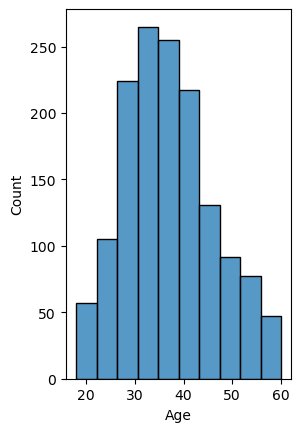

In [ ]:
plt.subplot(1,2,1)
sns.histplot(data=col,kde=False,legend=False,bins=10)
plt.plot()

[]

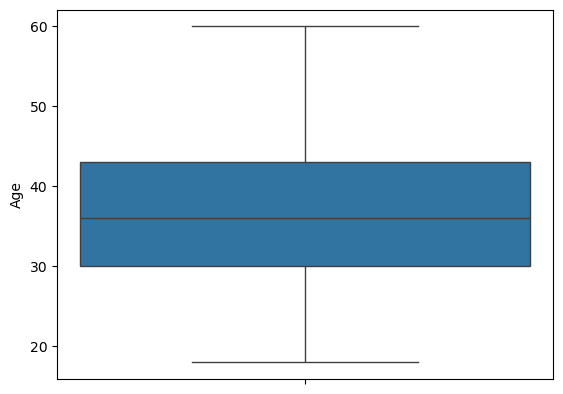

In [ ]:
sns.boxplot(df[coln])
plt.plot()

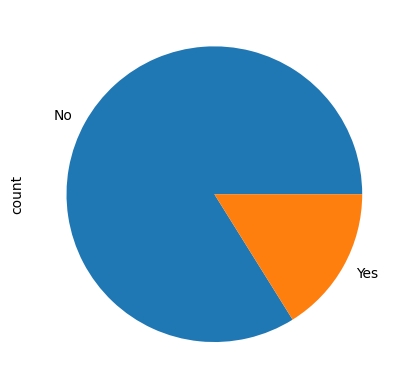

In [ ]:
colc=input('enter the column name: ')
if colc in cat_val:
    col=df[colc].value_counts()
    cho=input('enter the type of plot you want: ')
    if cho.lower()=='bar':
        col.plot(kind='bar')
        plt.show()
    elif cho.lower()=='pie':
        col.plot(kind='pie')
        plt.show()
    else:
        print("Wrong choice")
else:
    print('wrong choice-outer')

# **Program 2**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=sns.load_dataset('iris')
x='sepal_length'
y='petal_length'

In [ ]:
corr=df[['sepal_length','sepal_width']].corr('pearson')
cov=df[['sepal_length','sepal_width']].cov()
print(f'Correlation: {corr}\nCovariance: {cov}')

Correlation:               sepal_length  sepal_width
sepal_length       1.00000     -0.11757
sepal_width       -0.11757      1.00000
Covariance:               sepal_length  sepal_width
sepal_length      0.685694    -0.042434
sepal_width      -0.042434     0.189979


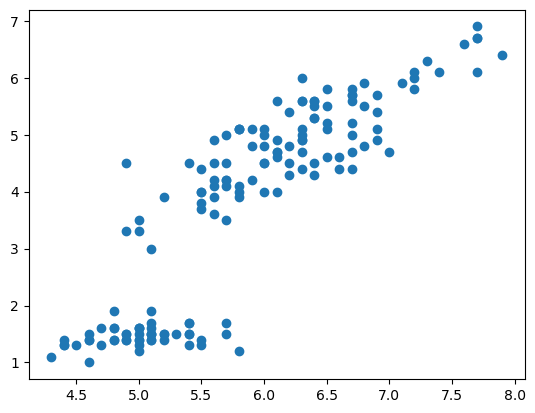

In [ ]:
plt.scatter(df[x],df[y])

In [ ]:
d=df.iloc[:,:-1]
cov=d.cov()
corr=d.corr()

<Axes: >

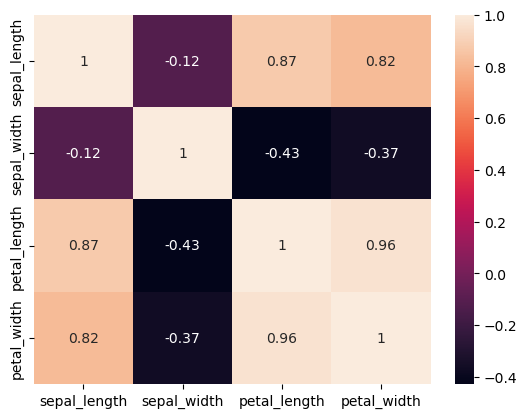

In [ ]:
sns.heatmap(corr,annot=True)

# **Program 3**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
iris=load_iris()
x=iris.data
y=iris.target

In [ ]:
sc=StandardScaler()
tr=sc.fit_transform(x)

In [ ]:
pc=PCA(n_components=2)
tpc=pc.fit_transform(tr)

In [ ]:
df=pd.DataFrame(data=tpc,columns=["PC1","PC2"])
df["Species"]=y

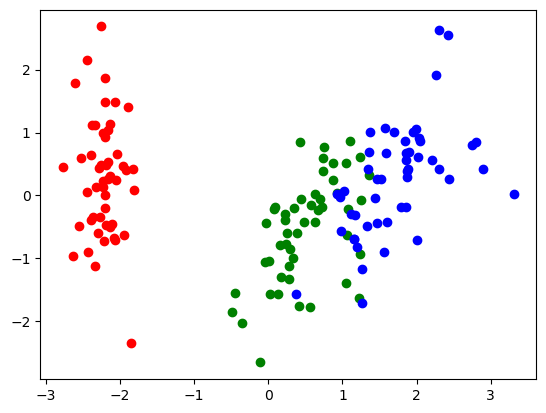

In [ ]:
colors=['red','green','blue']
for i, color in zip([0, 1, 2], colors):
    plt.scatter(
        df[df['Species'] == i]['PC1'],
        df[df['Species'] == i]['PC2'],
        color=color,
        label=iris.target_names[i]
    )
plt.show()

# **Program 4**

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score as ass, f1_score as f
from sklearn.model_selection import train_test_split as tts

In [ ]:
iris = load_iris()
x=iris.data ; y= iris.target
k_values=[1,3,5]

In [ ]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=43)

In [ ]:
def neighbor(x_train,x_test,y_train,y_test,k_val,weighted=False):
    accu={}
    for k in k_val:
        if weighted:
            knn=KNeighborsClassifier(n_neighbors=k, weights='distance')
        else:
            knn=KNeighborsClassifier(n_neighbors=k,weights='uniform')

        knn.fit(x_train,y_train)
        y_pred=knn.predict(x_test)
        acc=ass(y_test,y_pred)
        f1=f(y_test,y_pred,average='weighted')
        accu[k]={'Accuracy Score':acc,
            'f1 Score': f1}
    return accu



In [ ]:
wk=neighbor(x_train,x_test,y_train,y_test,k_values,weighted=True)
for i, met in wk.items():
    print(f"{i}={met['Accuracy Score']},{met['f1 Score']}")

1=1.0,1.0
3=1.0,1.0
5=1.0,1.0


In [ ]:
nk=neighbor(x_train,x_test,y_train,y_test,k_values,weighted=False)
for i, met in wk.items():
    print(f"{i}={met['Accuracy Score']},{met['f1 Score']}")

1=1.0,1.0
3=1.0,1.0
5=1.0,1.0


In [ ]:
for k in k_values:
    reg=nk[k]['Accuracy Score']
    wei=wk[k]['Accuracy Score']
    print(f'{k} {reg},{wei}')

1 1.0,1.0
3 1.0,1.0
5 1.0,1.0


In [2]:
import pandas as pd
df=pd.read_csv('/content/boston_housing_data.csv')
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

<function mean_squared_error at 0x78ccfdfa8f40>
0.46509247559266687


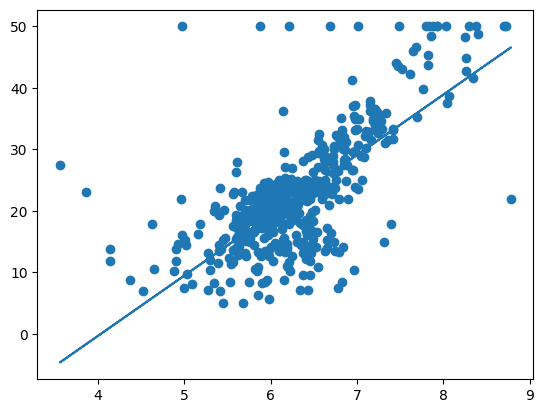

<function mean_squared_error at 0x78ccfdfa8f40>
0.6488422308298789


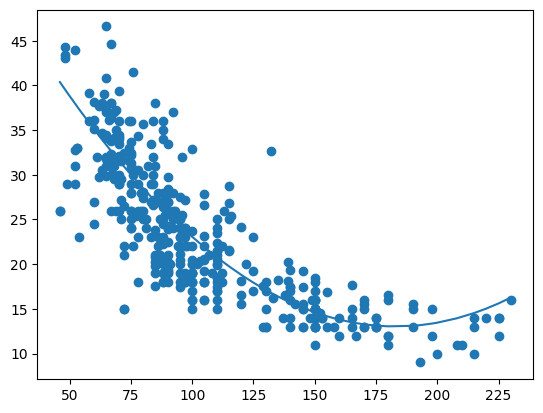

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error as mmse, r2_score as r22
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split as tts
df=pd.read_csv('/content/boston_housing_data.csv')
x=df[['RM']]
y=df[['MEDV']]
x_test,x_train,y_test,y_train=tts(x,y,test_size=0.2,random_state=43)
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
mse=mmse(y_test,y_pred)
r2=r22(y_test,y_pred)
print(f'{mmse}\n{r2}')
plt.scatter(x,y)
plt.plot(x_test,y_pred)
plt.show()
df=pd.read_csv('/content/auto-mpg.csv')
df['horsepower']=df['horsepower'].replace('?',np.nan).astype('float64')
df.dropna(inplace=True)
x=df[['horsepower']];y=df[['mpg']];
x_test,x_train,y_test,y_train=tts(x,y,test_size=0.2,random_state=43)
p=PolynomialFeatures(degree=2)
x_test_p=p.fit_transform(x_test)
x_train_p=p.fit_transform(x_train)
lr.fit(x_train_p,y_train)
y_pred=lr.predict(x_test_p)
mse=mmse(y_test,y_pred)
r2=r22(y_test,y_pred)
print(f'{mmse}\n{r2}')
plt.scatter(x,y)
sor=x_test.squeeze().argsort()
plt.plot(x_test.iloc[sor],y_pred[sor])

44.83819409322271
0.5138020913731223


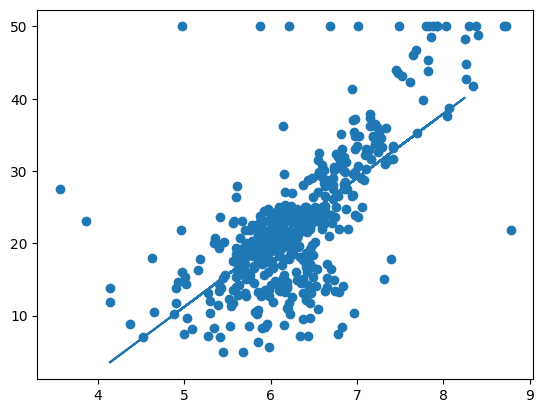

18.368222467152027
0.7238470909978687


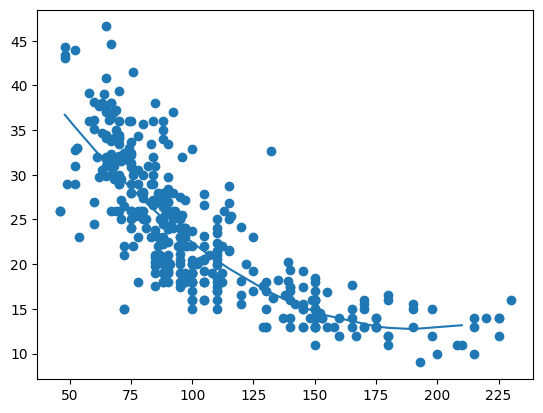

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error as mse, r2_score as r2
df=pd.read_csv('/content/boston_housing_data.csv')
x=df[['RM']]
y=df[['MEDV']]
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=43)
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
print(f"{mse(y_test,y_pred)}\n{r2(y_test,y_pred)}")
plt.scatter(x,y)
plt.plot(x_test,y_pred)
plt.show()
df=pd.read_csv('/content/auto-mpg.csv')
df['horsepower']=df['horsepower'].replace('?',np.nan).astype(float)
df.dropna(inplace=True)
x=df[['horsepower']] # Changed from df['horsepower'] to df[['horsepower']] to make it 2D
y=df['mpg']
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=43)
p=PolynomialFeatures(degree=2)
x_train_p=p.fit_transform(x_train)
x_test_p=p.fit_transform(x_test)
lr.fit(x_train_p,y_train)
y_pred=lr.predict(x_test_p)
print(f"{mse(y_test,y_pred)}\n{r2(y_test,y_pred)}")
plt.scatter(x,y)
sco=x_test.squeeze().argsort()
plt.plot(x_test.iloc[sco],y_pred[sco])

0.8041958041958042
              precision    recall  f1-score   support

           0       0.84      0.86      0.85        92
           1       0.73      0.71      0.72        51

    accuracy                           0.80       143
   macro avg       0.79      0.78      0.78       143
weighted avg       0.80      0.80      0.80       143



[Text(0.45689655172413796, 0.9, 'x[1] <= 0.5\ngini = 0.486\nsamples = 569\nvalue = [332, 237]'),
 Text(0.1896551724137931, 0.7, 'x[2] <= 6.5\ngini = 0.334\nsamples = 359\nvalue = [283, 76]'),
 Text(0.3232758620689655, 0.8, 'True  '),
 Text(0.06896551724137931, 0.5, 'x[3] <= 2.5\ngini = 0.388\nsamples = 19\nvalue = [5, 14]'),
 Text(0.034482758620689655, 0.3, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]'),
 Text(0.10344827586206896, 0.3, 'x[4] <= 1.5\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.06896551724137931, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.13793103448275862, 0.1, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.3103448275862069, 0.5, 'x[0] <= 1.5\ngini = 0.298\nsamples = 340\nvalue = [278, 62]'),
 Text(0.2413793103448276, 0.3, 'x[2] <= 43.5\ngini = 0.472\nsamples = 84\nvalue = [52, 32]'),
 Text(0.20689655172413793, 0.1, 'gini = 0.5\nsamples = 45\nvalue = [22, 23]'),
 Text(0.27586206896551724, 0.1, 'gini = 0.355\nsamples = 39\nvalue = [30, 9]'),
 Te

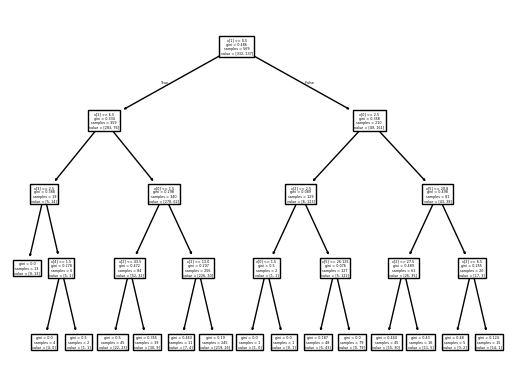

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split as tts
data=sns.load_dataset('titanic')
data.columns
f=['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare','embarked']
df=data[f]
df=df.dropna()
df['sex']=df['sex'].map({'male':0,'female':1})
df['embarked']=df['embarked'].map({'S':0,'C':1,'Q':2})
x=df.drop(columns=['survived'])
y=df['survived']
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=43)
cls=DecisionTreeClassifier(max_depth=4)
cls.fit(x_train,y_train)
y_pred=cls.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
plot_tree(cls)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.89      1.00      0.94         8
           2       1.00      0.89      0.94         9

    accuracy                           0.97        30
   macro avg       0.96      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30



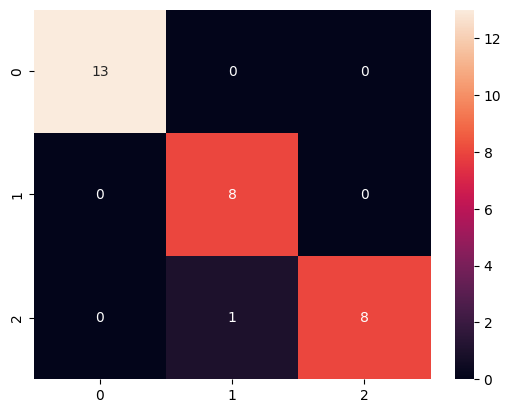

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix as cmm, classification_report as cr
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split as tts
data=load_iris()
x=data.data
y=data.target
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=43)
gb=GaussianNB()
gb.fit(x_train,y_train)
y_pred=gb.predict(x_test)
print(f"{cr(y_test,y_pred)}")
cm=cmm(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.show()

0.34338224069077816
0.6536246043910179


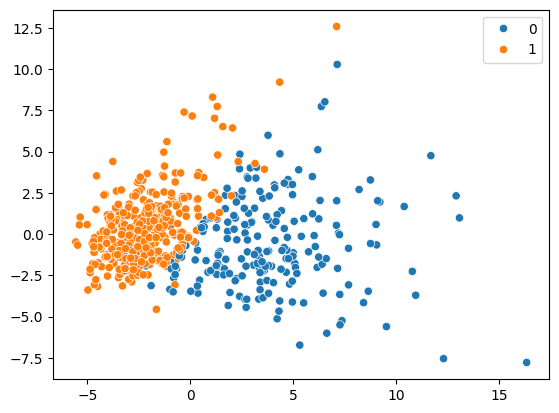

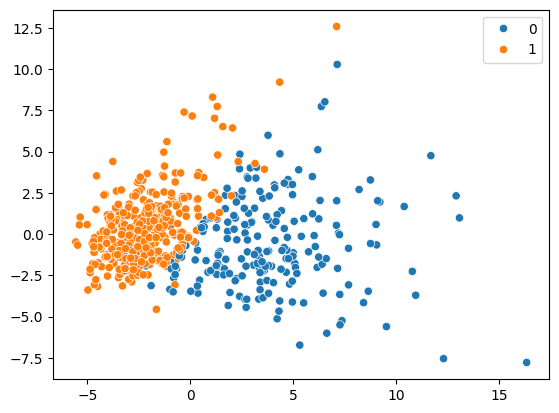

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score as si, adjusted_rand_score as ad
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
data=load_breast_cancer()
x=pd.DataFrame(data.data,columns=data.feature_names)
y=data.target

s=StandardScaler()
x_s=s.fit_transform(x)

k=KMeans(n_clusters=2,random_state=43)
y_m=k.fit_predict(x_s)
print(f"{si(x_s,y_m)}\n{ad(y,y_m)}")
p=PCA(n_components=2)
x_p=p.fit_transform(x_s)
sns.scatterplot(x=x_p[:,0],y=x_p[:,1],hue=y)
plt.show()
sns.scatterplot(x=x_p[:,0],y=x_p[:,1],hue=y)
plt.show()

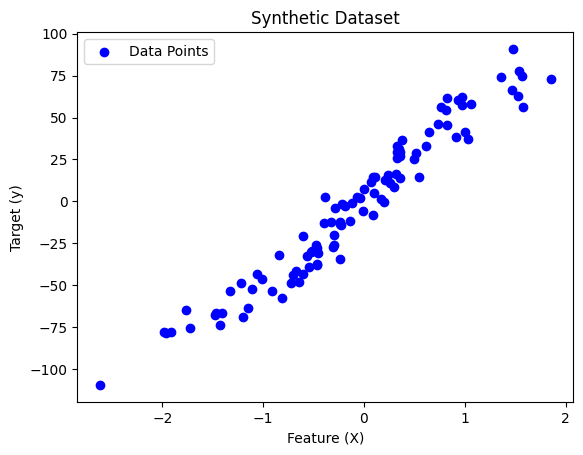

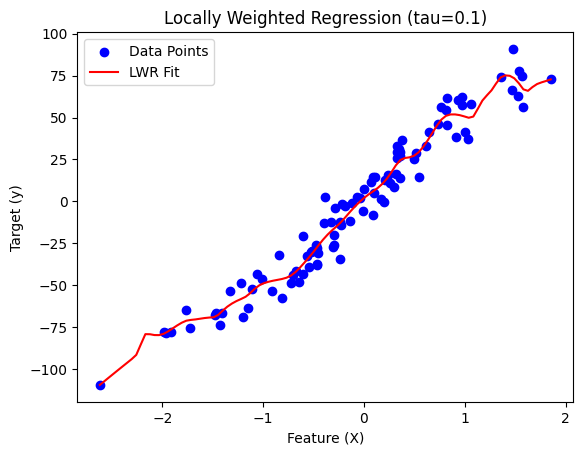

Mean Squared Error (MSE) on Training Data: 64.7316


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.metrics import mean_squared_error

# Generate a synthetic dataset
np.random.seed(42)
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
# Add some non-linearity to the dataset
y = y + 10 * np.sin(X[:, 0] * 2)

# Plot the dataset
plt.scatter(X, y, color='blue', label='Data Points')
plt.title("Synthetic Dataset")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.legend()
plt.show()

# Locally Weighted Regression function
def locally_weighted_regression (X, y, query_point, tau=0.1):
    # Compute weights using a Gaussian kernel
    weights = np.exp(-np.sum((X - query_point) ** 2, axis=1) / (2 * tau ** 2))
    # Add a bias term to X
    X_bias= np.c_[np.ones(X.shape[0]), X]
    # Compute the weighted least squares solution
    W= np.diag(weights)
    theta = np.linalg.inv(X_bias.T @ W @X_bias) @ (X_bias.T @ W @ y)
    # Predict the target value for the query point
    query_point_bias= np.array ([1, query_point[0]])
    y_pred = query_point_bias @ theta
    return y_pred

# Predict using Locally Weighted Regression
def predict_lwr (X_train, y_train, X_test, tau=0.1):
    y_pred = np.zeros(X_test.shape[0])
    for i, query_point in enumerate (X_test):
        y_pred[i] = locally_weighted_regression(X_train, y_train, query_point, tau)
    return y_pred

# Generate test points
X_test = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Predict using LWR
tau = 0.1 # Bandwidth parameter
y_pred = predict_lwr (X, y, X_test, tau)

# Plot the results
plt.scatter(X, y, color='blue', label='Data Points')
plt.plot(X_test, y_pred, color='red', label='LWR Fit')
plt.title(f"Locally Weighted Regression (tau={tau})")
plt.xlabel("Feature (X)")
plt.ylabel("Target (y)")
plt.legend()
plt.show()

# Evaluate the model
mse = mean_squared_error(y, predict_lwr (X, y, X, tau))
print (f"Mean Squared Error (MSE) on Training Data: {mse:.4f}")

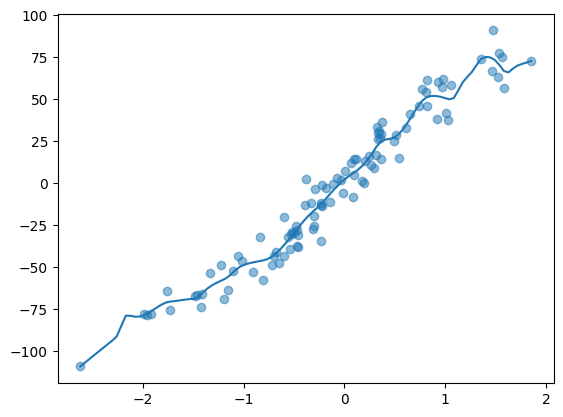

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
y += 10 * np.sin(X[:, 0] * 2)
X_test = np.linspace(X.min(), X.max(), 100)

def lwr_predict(X, y, q, tau=0.1):

    weights = np.exp(-((X - q)**2).sum(axis=1) / (2 * tau**2))
    W = np.diag(weights)


    X_b = np.c_[np.ones(len(X)), X]
    query_b = [1, q]


    theta = np.linalg.lstsq(X_b.T @ W @ X_b, X_b.T @ W @ y, rcond=None)[0]
    return query_b @ theta

# 2. Generate Predictions
tau = 0.1
y_pred = [lwr_predict(X, y, q, tau) for q in X_test]

# 3. Plot
plt.scatter(X, y, alpha=0.5)
plt.plot(X_test, y_pred)
plt.show()

In [53]:
!pip install pylwl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
plotnine 0.14.5 requires pandas>=2.2.0, but you have pandas 2.1.4 which is incompatible.
rasterio 1.5.0 requires nump

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from pylwl import LWR

# 1. Setup Data
X, y = make_regression(n_samples=100, n_features=1, noise=10, random_state=42)
y += 10 * np.sin(X[:, 0] * 2)
X_test = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# 2. Initialize and "Fit" the model
# In LWR, 'fitting' just means storing the data for later lookup
model = LWR(tau=0.1)
model.fit(X, y)

# 3. Predict
# pylwl handles the loop over X_test automatically
y_pred = model.predict(X_test)

# 4. Plot
plt.scatter(X, y, alpha=0.5, label="Data")
plt.plot(X_test, y_pred, color='green', lw=2, label="pylwl Fit")
plt.legend(); plt.show()

ImportError: cannot import name 'LWR' from 'pylwl' (/usr/local/lib/python3.12/dist-packages/pylwl/__init__.py)

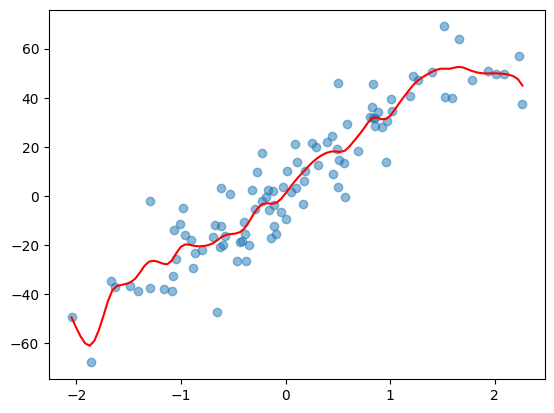

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
x,y=make_regression(n_features=1,n_samples=100,noise=10,random_state=43)
y+=10*np.sin(x[:,0]**2)
x_test=np.linspace(x.max(),x.min(),100)
def lwr(x,y,q,tau=0.1):
  w=np.exp(-((x-q)**2).sum(axis=1)/(2*tau**2))
  wp=np.diag(w)
  x_b=np.c_[np.ones(len(x)),x]
  q_b=[1,q]
  theta=np.linalg.lstsq(x_b.T @wp @x_b, x_b.T @wp @y, rcond=True)[0]
  return q_b @ theta
t=0.1
y_pred=[lwr(x,y,q,t)for q in x_test]
plt.scatter(x,y,alpha=0.5)
plt.plot(x_test,y_pred,color='r')
plt.show()

## **Practice**

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#6

18.368222467152027
0.7238470909978687


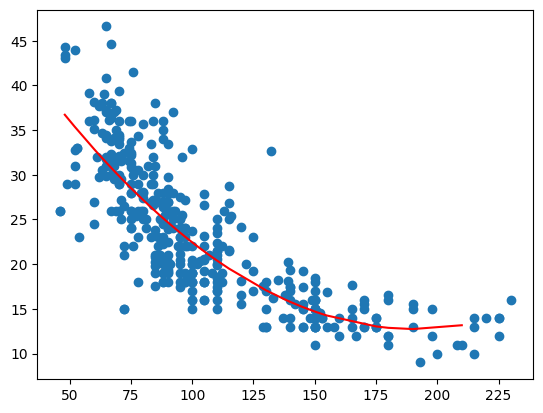

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import mean_squared_error as msee, r2_score as r2
df=pd.read_csv('/content/auto-mpg.csv')
df['horsepower']=df['horsepower'].replace('?',np.nan).astype(float)
df.dropna(inplace=True)
x=df[['horsepower']]
y=df[['mpg']]
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=43)
p=PolynomialFeatures(degree=2)
x_train_p=p.fit_transform(x_train)
x_test_p=p.fit_transform(x_test)
lr=LinearRegression()
lr.fit(x_train_p,y_train)
y_pred=lr.predict(x_test_p)
print(f"{msee(y_test,y_pred)}\n{r2(y_test,y_pred)}")
plt.scatter(x,y)
sor=x_test.squeeze().argsort()
plt.plot(x_test.iloc[sor],y_pred[sor],color='r')
plt.show()

44.83819409322271
0.5138020913731223


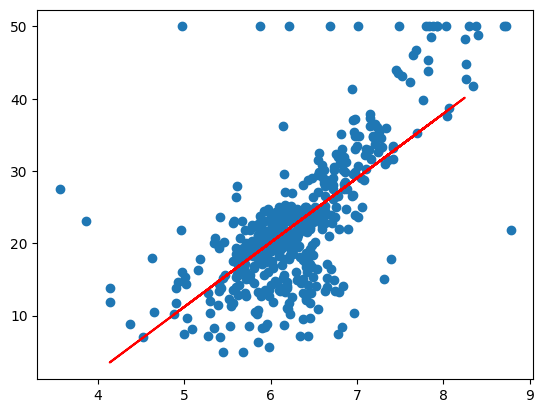

In [16]:
df=pd.read_csv('/content/boston_housing_data.csv')
df.columns
x=df[['RM']]
y=df[['MEDV']]
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=43)
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)
print(f"{msee(y_test,y_pred)}\n{r2(y_test,y_pred)}")
plt.scatter(x,y)
plt.plot(x_test,y_pred,color='r')
plt.show()

#7

0.8041958041958042
              precision    recall  f1-score   support

           0       0.84      0.86      0.85        92
           1       0.73      0.71      0.72        51

    accuracy                           0.80       143
   macro avg       0.79      0.78      0.78       143
weighted avg       0.80      0.80      0.80       143



[Text(0.45689655172413796, 0.9, 'x[1] <= 0.5\ngini = 0.486\nsamples = 569\nvalue = [332, 237]'),
 Text(0.1896551724137931, 0.7, 'x[2] <= 6.5\ngini = 0.334\nsamples = 359\nvalue = [283, 76]'),
 Text(0.3232758620689655, 0.8, 'True  '),
 Text(0.06896551724137931, 0.5, 'x[3] <= 2.5\ngini = 0.388\nsamples = 19\nvalue = [5, 14]'),
 Text(0.034482758620689655, 0.3, 'gini = 0.0\nsamples = 13\nvalue = [0, 13]'),
 Text(0.10344827586206896, 0.3, 'x[4] <= 1.5\ngini = 0.278\nsamples = 6\nvalue = [5, 1]'),
 Text(0.06896551724137931, 0.1, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]'),
 Text(0.13793103448275862, 0.1, 'gini = 0.5\nsamples = 2\nvalue = [1, 1]'),
 Text(0.3103448275862069, 0.5, 'x[0] <= 1.5\ngini = 0.298\nsamples = 340\nvalue = [278, 62]'),
 Text(0.2413793103448276, 0.3, 'x[2] <= 43.5\ngini = 0.472\nsamples = 84\nvalue = [52, 32]'),
 Text(0.20689655172413793, 0.1, 'gini = 0.5\nsamples = 45\nvalue = [22, 23]'),
 Text(0.27586206896551724, 0.1, 'gini = 0.355\nsamples = 39\nvalue = [30, 9]'),
 Te

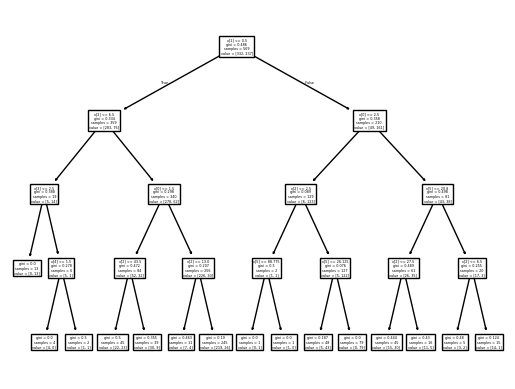

In [27]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score as acs, classification_report as cr
from sklearn.model_selection import train_test_split as tts
data=sns.load_dataset('titanic')
data.columns
f=['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare','embarked']
df=data[f]
df=df.dropna()
df['sex']=df['sex'].map({'male':0,'female':1})
df['embarked']=df['embarked'].map({'S':0,'C':1,'Q':2})
x=df.drop(columns=['survived'])
y=df['survived']
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=43)
cls=DecisionTreeClassifier(max_depth=4)
cls.fit(x_train,y_train)
y_pred=cls.predict(x_test)
print(f"{acs(y_test,y_pred)}\n{cr(y_test,y_pred)}")
plot_tree(cls)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.89      1.00      0.94         8
           2       1.00      0.89      0.94         9

    accuracy                           0.97        30
   macro avg       0.96      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30



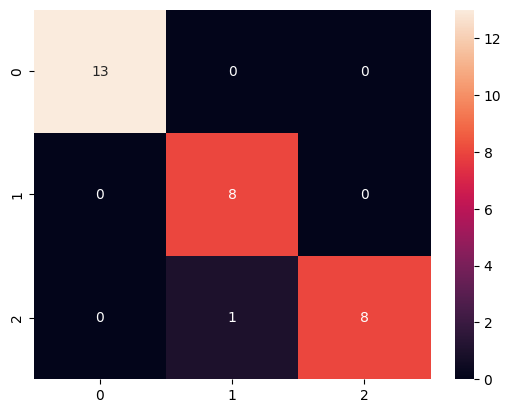

In [30]:
from sklearn.metrics import classification_report as cr, confusion_matrix as cmm
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split as tts
from sklearn.datasets import load_iris
data=load_iris()
x=data.data
y=data.target
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=43)
gb=GaussianNB()
gb.fit(x_train,y_train)
y_pred=gb.predict(x_test)
print(f"{cr(y_test,y_pred)}")
cm=cmm(y_test,y_pred)
sns.heatmap(cm,annot=True)
plt.show()


0.34338224069077816
0.6536246043910179


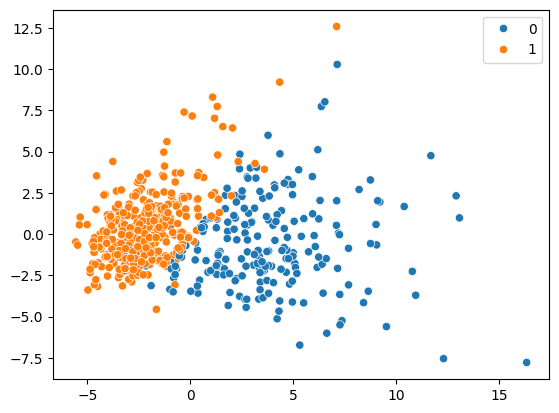

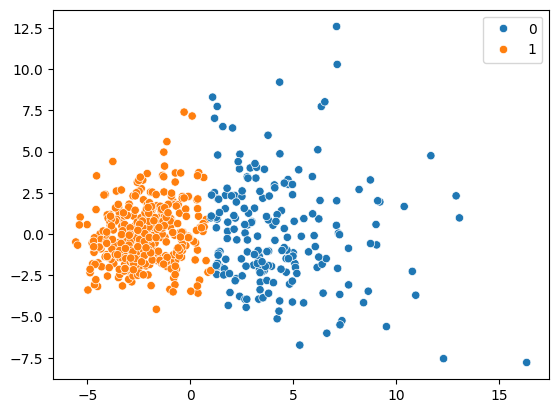

In [32]:
from sklearn.metrics import silhouette_score as sil, adjusted_rand_score as adj
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split as tts
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
data=load_breast_cancer()
x=pd.DataFrame(data.data,columns=data.feature_names)
y=data.target
s=StandardScaler()
x_s=s.fit_transform(x)
k=KMeans(n_clusters=2,random_state=43)
y_m=k.fit_predict(x_s)
print(f"{sil(x_s,y_m)}\n{adj(y,y_m)}")
p=PCA(n_components=2)
x_p=p.fit_transform(x_s)
sns.scatterplot(x=x_p[:,0],y=x_p[:,1],hue=y)
plt.show()
sns.scatterplot(x=x_p[:,0],y=x_p[:,1],hue=y_m)
plt.show()

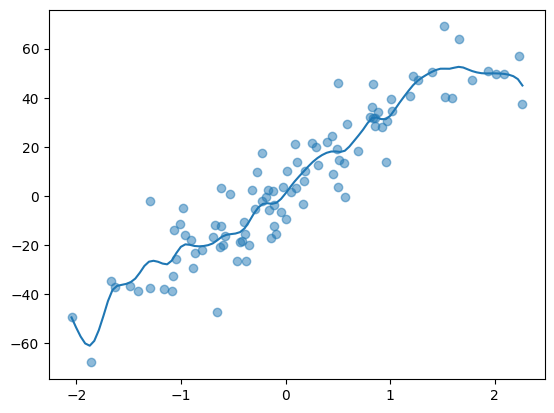

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
x,y=make_regression(n_samples=100,n_features=1,noise=10,random_state=43)
y+=10*np.sin(x[:,0]**2)
x_test=np.linspace(x.max(),x.min(),100)
def lwr(x,y,q,tau=0.1):
  w=np.exp(-((x-q)**2).sum(axis=1)/(2*tau**2))
  wp=np.diag(w)
  x_b=np.c_[np.ones(len(x)),x]
  q_b=[1,q]
  theta=np.linalg.lstsq(x_b.T @wp @x_b, x_b.T @wp @ y, rcond=True)[0]
  return q_b @ theta
t=0.1
y_pred=[lwr(x,y,q,t)for q in x_test]
plt.scatter(x,y,alpha=0.5)
plt.plot(x_test,y_pred)
plt.show()
